In [13]:
import os
import numpy as np
import pandas as pd
import nmrglue as ng
import matplotlib.pyplot as plt


# =========================
# CONFIG
# =========================
INPUT_FOLDER = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"
OUTPUT_FOLDER = os.path.join(INPUT_FOLDER, "diagnose")

os.makedirs(OUTPUT_FOLDER, exist_ok=True)


# =========================
# SAFE FLOAT
# =========================
def safe_float(value, default=0.0):
    if isinstance(value, list):
        value = value[0] if value else default
    try:
        return float(value)
    except:
        return default


# =========================
# MAIN DIAGNOSTIC FUNCTION
# =========================
def diagnose(jcamp_path, output_folder):

    print("\n" + "=" * 70)
    print("RUNNING:", os.path.basename(jcamp_path))
    print("=" * 70)

    stem = os.path.splitext(os.path.basename(jcamp_path))[0]

    # -------------------------
    # 1. RAW HEADER
    # -------------------------
    header_vals = {}

    with open(jcamp_path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if line.startswith("##") and "=" in line:
                key, _, val = line[2:].partition("=")
                header_vals[key.strip().upper()] = val.strip()
            if line == "##END=":
                break

    yfactor_raw = float(header_vals.get("YFACTOR", "1.0"))

    print("[Header] YFACTOR:", yfactor_raw)

    # -------------------------
    # 2. READ DATA
    # -------------------------
    dic, data = ng.jcampdx.read(jcamp_path)
    data = np.asarray(data, dtype=np.float64)

    print("[Data] shape:", data.shape, "max:", np.abs(data).max())

    # -------------------------
    # 3. YFACTOR CHECK
    # -------------------------
    data_max = np.abs(data).max()

    if data_max > 1e8:
        yfactor_applied = False
    else:
        yfactor_applied = True

    # -------------------------
    # 4. X AXIS
    # -------------------------
    firstx = safe_float(dic.get("FIRSTX"), 0.0)
    lastx  = safe_float(dic.get("LASTX"), 0.0)
    deltax = safe_float(dic.get("DELTAX"), 0.0)

    npoints = len(data)

    if (deltax == 0.0 or np.isnan(deltax)) and lastx != 0.0:
        deltax = (lastx - firstx) / (npoints - 1)

    x = firstx + np.arange(npoints) * deltax

    # NMR direction fix
    if len(x) > 1 and x[0] < x[-1]:
        x = x[::-1]
        data = data[::-1]

    # -------------------------
    # 5. APPLY YFACTOR IF NEEDED
    # -------------------------
    y = data.copy()

    if not yfactor_applied:
        y = y * yfactor_raw
        print("[FIX] Applied YFACTOR")

    # -------------------------
    # 6. SAVE CSV
    # -------------------------
    csv_path = os.path.join(output_folder, f"{stem}_FIXED.csv")

    pd.DataFrame({
        "chemical_shift_ppm": x,
        "intensity": y
    }).to_csv(csv_path, index=False)

    # -------------------------
    # 7. PLOT
    # -------------------------
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))

    # raw
    axes[0].plot(x, data, lw=0.8)
    axes[0].set_title("Raw")
    axes[0].invert_xaxis()
    axes[0].grid(alpha=0.3)

    # fixed
    axes[1].plot(x, y, lw=0.8, color="red")
    axes[1].set_title("Fixed")
    axes[1].invert_xaxis()
    axes[1].grid(alpha=0.3)

    plot_path = os.path.join(output_folder, f"{stem}_DIAGNOSTIC.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=120)
    plt.close()

    print("[Saved]", csv_path)
    print("[Saved]", plot_path)

    return csv_path, plot_path


# =========================
# BATCH RUNNER (SAFE)
# =========================
files = [
    f for f in os.listdir(INPUT_FOLDER)
    if f.lower().endswith(".jdx")
]

print("FOUND FILES:", len(files))


success = 0
failed = 0

for f in files:
    path = os.path.join(INPUT_FOLDER, f)

    try:
        diagnose(path, OUTPUT_FOLDER)
        print("✔ SUCCESS:", f)
        success += 1

    except Exception as e:
        print("FAILED:", f)
        print("   ERROR:", str(e))
        failed += 1


print("\n====================")
print("DONE")
print("Success:", success)
print("Failed:", failed)
print("Output folder:", OUTPUT_FOLDER)

FOUND FILES: 1506

RUNNING: 001_100MHz.jdx
[Header] YFACTOR: 0.046566128752457976
[Data] shape: (4096,) max: 100000000.00000001
[FIX] Applied YFACTOR


c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: ORIGIN
  warn(f"JCAMP-DX key without value: {key}")
c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: OWNER
  warn(f"JCAMP-DX key without value: {key}")


[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\001_100MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\001_100MHz_DIAGNOSTIC.png
✔ SUCCESS: 001_100MHz.jdx

RUNNING: 001_500MHz.jdx
[Header] YFACTOR: 0.04656612875245797
[Data] shape: (4096,) max: 100000000.0


c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: ORIGIN
  warn(f"JCAMP-DX key without value: {key}")
c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: OWNER
  warn(f"JCAMP-DX key without value: {key}")


[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\001_500MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\001_500MHz_DIAGNOSTIC.png
✔ SUCCESS: 001_500MHz.jdx

RUNNING: 001_60MHz.jdx
[Header] YFACTOR: 0.046566128752457976
[Data] shape: (4096,) max: 100000000.00000001
[FIX] Applied YFACTOR
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\001_60MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\001_60MHz_DIAGNOSTIC.png
✔ SUCCESS: 001_60MHz.jdx

RUNNING: 002_100MHz.jdx
[Header] YFACTOR: 0.04656612875245797
[Data] shape: (4096,) max: 100000000.0


...

[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\501_60MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\501_60MHz_DIAGNOSTIC.png
✔ SUCCESS: 501_60MHz.jdx

RUNNING: 502_100MHz.jdx
[Header] YFACTOR: 0.04656612875245797
[Data] shape: (4096,) max: 100000000.0
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\502_100MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\502_100MHz_DIAGNOSTIC.png
✔ SUCCESS: 502_100MHz.jdx

RUNNING: 502_500MHz.jdx


c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: ORIGIN
  warn(f"JCAMP-DX key without value: {key}")
c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: OWNER
  warn(f"JCAMP-DX key without value: {key}")


[Header] YFACTOR: 0.04656612875245797
[Data] shape: (4096,) max: 100000000.0
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\502_500MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\502_500MHz_DIAGNOSTIC.png
✔ SUCCESS: 502_500MHz.jdx

RUNNING: 502_60MHz.jdx
[Header] YFACTOR: 0.04656612875245797
[Data] shape: (4096,) max: 100000000.0


c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: ORIGIN
  warn(f"JCAMP-DX key without value: {key}")
c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: OWNER
  warn(f"JCAMP-DX key without value: {key}")
c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: ORIGIN
  warn(f"JCAMP-DX key without value: {key}")
c:\Users\pljh0187\AppData\Local\miniforge3\envs\pyenv\Lib\site-packages\nmrglue\fileio\jcampdx.py:88: UserWarning: JCAMP-DX key without value: OWNER
  warn(f"JCAMP-DX key without value: {key}")


[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\502_60MHz_FIXED.csv
[Saved] C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose\502_60MHz_DIAGNOSTIC.png
✔ SUCCESS: 502_60MHz.jdx

DONE
Success: 1506
Failed: 0
Output folder: C:\Users\pljh0187\Desktop\Senushi\JCAMP files\diagnose


In [7]:
import os

folder = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"

files = os.listdir(folder)

for f in files:
    print(f)

001_100MHz.jdx
001_500MHz.jdx
001_60MHz.jdx
002_100MHz.jdx
002_500MHz.jdx
002_60MHz.jdx
003_100MHz.jdx
003_500MHz.jdx
003_60MHz.jdx
004_100MHz.jdx
004_500MHz.jdx
004_60MHz.jdx
005_100MHz.jdx
005_500MHz.jdx
005_60MHz.jdx
006_100MHz.jdx
006_500MHz.jdx
006_60MHz.jdx
007_100MHz.jdx
007_500MHz.jdx
007_60MHz.jdx
008_100MHz.jdx
008_500MHz.jdx
008_60MHz.jdx
009_100MHz.jdx
009_500MHz.jdx
009_60MHz.jdx
010_100MHz.jdx
010_500MHz.jdx
010_60MHz.jdx
011_100MHz.jdx
011_500MHz.jdx
011_60MHz.jdx
012_100MHz.jdx
012_500MHz.jdx
012_60MHz.jdx
013_100MHz.jdx
013_500MHz.jdx
013_60MHz.jdx
014_100MHz.jdx
014_500MHz.jdx
014_60MHz.jdx
015_100MHz.jdx
015_500MHz.jdx
015_60MHz.jdx
016_100MHz.jdx
016_500MHz.jdx
016_60MHz.jdx
017_100MHz.jdx
017_500MHz.jdx
017_60MHz.jdx
018_100MHz.jdx
018_500MHz.jdx
018_60MHz.jdx
019_100MHz.jdx
019_500MHz.jdx
019_60MHz.jdx
020_100MHz.jdx
020_500MHz.jdx
020_60MHz.jdx
021_100MHz.jdx
021_500MHz.jdx
021_60MHz.jdx
022_100MHz.jdx
022_500MHz.jdx
022_60MHz.jdx
023_100MHz.jdx
023_500MHz.jdx
02

In [8]:
[c for c in os.listdir(folder) if c.endswith("_FIXED.csv")]

[]

In [9]:
[p for p in os.listdir(folder) if "_DIAGNOSTIC.png" in p]

[]

In [10]:
csv_files = [c for c in os.listdir(folder) if c.endswith("_FIXED.csv")]
png_files = [p for p in os.listdir(folder) if "_DIAGNOSTIC.png" in p]

print("CSV files saved:", len(csv_files))
print("Plots saved:", len(png_files))

CSV files saved: 0
Plots saved: 0


In [11]:
folder = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"

files = [f for f in os.listdir(folder) if f.endswith(".jdx")]

print("Files found:", len(files))
print(files[:5])

Files found: 1506
['001_100MHz.jdx', '001_500MHz.jdx', '001_60MHz.jdx', '002_100MHz.jdx', '002_500MHz.jdx']


--- Processing Compound 009 ---


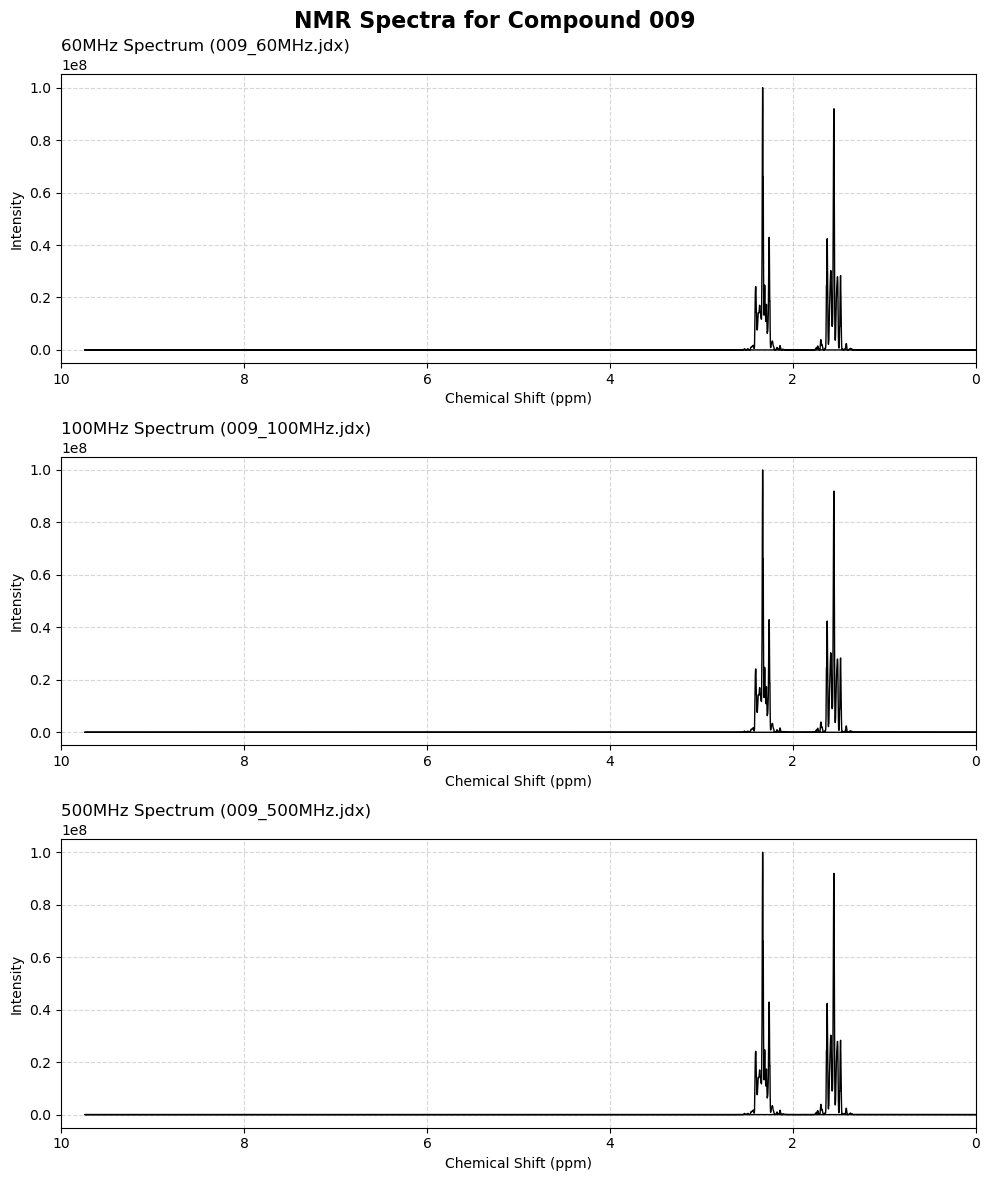

--- Processing Compound 018 ---


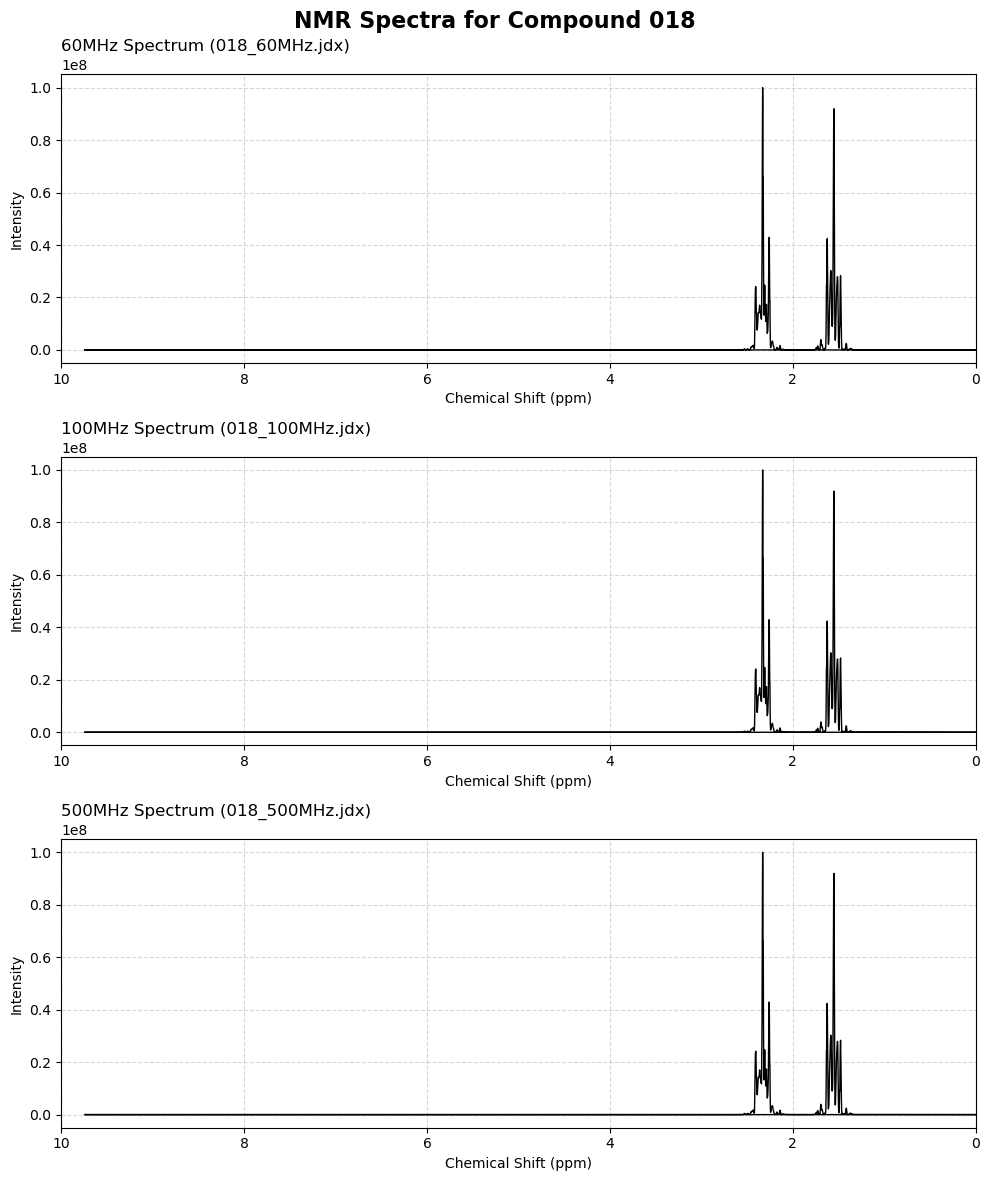

--- Processing Compound 024 ---


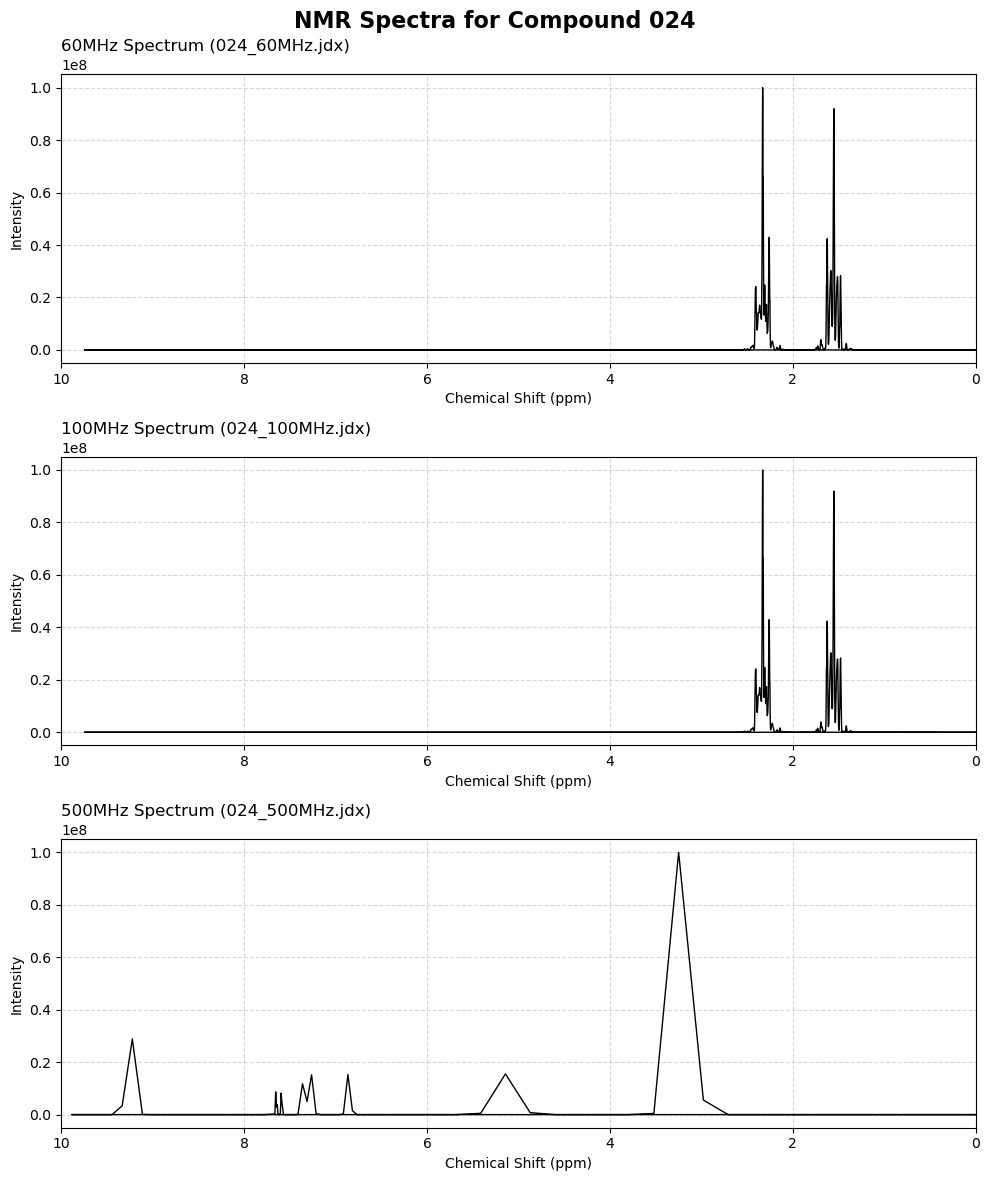

In [20]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from jcamp import jcamp_readfile  # Corrected import function name

# Define the base directory (Raw string 'r' prevents Windows backslash errors)
BASE_DIR = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"

# Targets specified by you
target_compounds = ["009", "018", "024"]
target_frequencies = ["60MHz", "100MHz", "500MHz"]

# Loop through each chosen compound
for compound in target_compounds:
    print(f"--- Processing Compound {compound} ---")
    
    # Create a clean vertical layout for the 3 frequencies
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)
    fig.suptitle(f"NMR Spectra for Compound {compound}", fontsize=16, fontweight='bold')
    
    plotted_any = False
    
    # Loop through each frequency subplot
    for idx, freq in enumerate(target_frequencies):
        ax = axes[idx]
        
        # Wildcard search for files matching compound and frequency (e.g., *009*60MHz*.*)
        search_pattern = os.path.join(BASE_DIR, f"*{compound}*{freq}*.*")
        matching_files = glob.glob(search_pattern)
        
        if not matching_files:
            ax.text(0.5, 0.5, f"File not found for {freq}", transform=ax.transAxes, 
                    ha='center', va='center', color='red', fontsize=12)
            ax.set_title(f"{freq} Spectrum")
            continue
            
        file_path = matching_files[0]
        file_name = os.path.basename(file_path)
        
        try:
            # 1. Read and automatically decompress the nmrdb.org DIFDUP format
            jcamp_dict = jcamp_readfile(file_path)
            
            # 2. Extract arrays
            x_data = np.array(jcamp_dict['x'])
            y_data = np.array(jcamp_dict['y'])
            
            # 3. Plot the spectrum
            ax.plot(x_data, y_data, color='black', linewidth=1)
            
            # NMR Convention: High ppm on the left, low ppm on the right
            # Range matches the header file (FIRSTX=0, LASTX=10)
            ax.set_xlim(10, 0) 
            
            # Style the subplot
            ax.set_title(f"{freq} Spectrum ({file_name})", fontsize=12, loc='left')
            ax.set_xlabel("Chemical Shift (ppm)", fontsize=10)
            ax.set_ylabel("Intensity", fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.5)
            
            plotted_any = True
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Error parsing file:\n{str(e)}", transform=ax.transAxes, 
                    ha='center', va='center', color='darkorange', fontsize=10)
            ax.set_title(f"{freq} Spectrum (Error)")
            
    # Display the final image for the compound
    if plotted_any:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)
        print(f"Skipping plot display for {compound}: No files found.")

In [21]:
import os
import glob

jdx_folder = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"
jdx_files = sorted(glob.glob(os.path.join(jdx_folder, "*.jdx")))

print(f"Total files: {len(jdx_files)}\n")

freq_mismatches = []
truncated = []

for path in jdx_files:
    fname = os.path.basename(path)
    
    # Determine expected frequency from filename
    expected_freq = None
    for tag in ['60MHz', '100MHz', '500MHz']:
        if tag in fname:
            expected_freq = tag.replace('MHz', '')
            break
    
    observed_freq = None
    line_count = 0
    xydata_lines = 0
    in_xydata = False
    
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            line_count += 1
            if line.startswith('##.OBSERVE FREQUENCY='):
                observed_freq = line.split('=')[1].strip()
            if line.startswith('##XYDATA'):
                in_xydata = True
            elif in_xydata and line.startswith('##'):
                in_xydata = False
            elif in_xydata:
                xydata_lines += 1
    
    # Check frequency mismatch
    if expected_freq and observed_freq and expected_freq != observed_freq:
        freq_mismatches.append(
            f"{fname}: expected {expected_freq} MHz, got {observed_freq} MHz"
        )
    
    # Flag truncated files (60/100 MHz should have ~45+ XYDATA lines, 500 MHz ~45+ too)
    if xydata_lines < 20:
        truncated.append(f"{fname}: only {xydata_lines} XYDATA lines")

print(f"=== FREQUENCY MISMATCHES ({len(freq_mismatches)}) ===")
for m in freq_mismatches:
    print(" ", m)

print(f"\n=== TRUNCATED FILES ({len(truncated)}) ===")
for t in truncated:
    print(" ", t)

print(f"\n=== SUMMARY ===")
print(f"Mismatched: {len(freq_mismatches)}")
print(f"Truncated:  {len(truncated)}")

Total files: 1506

=== FREQUENCY MISMATCHES (968) ===
  002_100MHz.jdx: expected 100 MHz, got 500 MHz
  002_60MHz.jdx: expected 60 MHz, got 500 MHz
  007_500MHz.jdx: expected 500 MHz, got 100 MHz
  008_500MHz.jdx: expected 500 MHz, got 100 MHz
  008_60MHz.jdx: expected 60 MHz, got 100 MHz
  009_500MHz.jdx: expected 500 MHz, got 100 MHz
  009_60MHz.jdx: expected 60 MHz, got 100 MHz
  010_500MHz.jdx: expected 500 MHz, got 100 MHz
  010_60MHz.jdx: expected 60 MHz, got 100 MHz
  011_500MHz.jdx: expected 500 MHz, got 100 MHz
  011_60MHz.jdx: expected 60 MHz, got 100 MHz
  012_500MHz.jdx: expected 500 MHz, got 100 MHz
  012_60MHz.jdx: expected 60 MHz, got 100 MHz
  013_500MHz.jdx: expected 500 MHz, got 100 MHz
  013_60MHz.jdx: expected 60 MHz, got 100 MHz
  014_500MHz.jdx: expected 500 MHz, got 100 MHz
  014_60MHz.jdx: expected 60 MHz, got 100 MHz
  015_500MHz.jdx: expected 500 MHz, got 100 MHz
  015_60MHz.jdx: expected 60 MHz, got 100 MHz
  016_500MHz.jdx: expected 500 MHz, got 100 MHz
  01

In [26]:
import pyautogui
import pyperclip
import time
import pandas as pd
import os
import shutil
import glob
from datetime import datetime

pyautogui.FAILSAFE = False
pyautogui.PAUSE = 0.05

# ========== CALIBRATION ==========
SMILES_FIELD    = (201, 253)
SIMULATE_BTN    = (268, 692)
JCAMP_BTN       = (1205, 626)

FREQ_DROPDOWN   = (184, 766)
FREQ_60_MHz     = (155, 794)
FREQ_100_MHz    = (157, 814)
FREQ_500_MHz    = (155, 907)

NPOINTS_DROPDOWN = (182, 863)
NPOINTS_4K       = (158, 674)

SAVE_FOLDER      = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files_test"
DOWNLOADS        = r"C:\Users\pljh0187\Downloads"
LOG_FILE         = os.path.join(r"C:\Users\pljh0187\Desktop\Senushi", "automation_log_book3.txt")

FREQ_OPTIONS = [
    (60,  FREQ_60_MHz),
    (100, FREQ_100_MHz),
    (500, FREQ_500_MHz),
]

# ========== READ Book3.csv ==========
CSV_PATH = r"C:\Users\pljh0187\Desktop\Senushi\Book3.csv"
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

if 'ID' not in df.columns:
    raise KeyError("Book3.csv must have an 'ID' column")
if 'Name' not in df.columns:
    raise KeyError("Book3.csv must have a 'Name' column")
if 'SMILES' not in df.columns:
    raise KeyError("Book3.csv must have a 'SMILES' column")

df['ID'] = df['ID'].astype(str).str.zfill(3)

# *** ONLY FIRST 5 COMPOUNDS ***
compounds = list(zip(df['ID'], df['Name'].str.strip(), df['SMILES'].str.strip()))[:5]
total = len(compounds)
print(f"Loaded {total} compounds (test run — first 5 only)")

os.makedirs(SAVE_FOLDER, exist_ok=True)
# ====================================

def safe_filename(compound_id, freq):
    return f"{compound_id}_{freq}MHz.jdx"

def log(message):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {message}"
    print(line)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")

def wait_for_download(before_files, timeout=15):
    for _ in range(timeout * 2):
        time.sleep(0.5)
        current = set(glob.glob(os.path.join(DOWNLOADS, "*.jdx")) +
                      glob.glob(os.path.join(DOWNLOADS, "predictedSpectrum*")))
        new_files = current - before_files
        if new_files:
            return new_files.pop()
    return None

def rename_download(downloaded_path, compound_id, freq_mhz):
    filename = safe_filename(compound_id, freq_mhz)
    dest = os.path.join(SAVE_FOLDER, filename)
    shutil.move(downloaded_path, dest)
    return dest

def hover_and_paste(x, y, text, delay=0.8):
    pyperclip.copy(text)
    pyautogui.moveTo(x, y, duration=0.4)
    time.sleep(0.3)
    pyautogui.hotkey('ctrl', 'v')
    time.sleep(delay)

def hover_and_left_click_dropdown(x, y, delay=0.5):
    pyautogui.moveTo(x, y, duration=0.4)
    time.sleep(0.2)
    pyautogui.click()
    time.sleep(delay)

def hover_and_left_click(x, y, delay=0.5):
    pyautogui.moveTo(x, y, duration=0.4)
    time.sleep(0.2)
    pyautogui.click()
    time.sleep(delay)

def wait_and_click(x, y, delay=0.8):
    pyautogui.moveTo(x, y, duration=0.4)
    pyautogui.click()
    time.sleep(delay)

def clear_smiles_field():
    pyautogui.moveTo(*SMILES_FIELD, duration=0.4)
    time.sleep(0.2)
    pyautogui.hotkey('ctrl', 'a')
    time.sleep(0.1)
    pyautogui.press('delete')
    time.sleep(0.3)

def select_frequency(freq_mhz, freq_coord):
    hover_and_left_click_dropdown(*FREQ_DROPDOWN)
    hover_and_left_click(*freq_coord)

def select_4k_points():
    hover_and_left_click_dropdown(*NPOINTS_DROPDOWN)
    hover_and_left_click(*NPOINTS_4K)

def verify_downloaded_freq(path, expected_freq):
    """Read the OBSERVE FREQUENCY header and compare to expected."""
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if line.startswith('##.OBSERVE FREQUENCY='):
                actual = line.split('=')[1].strip()
                return actual, str(expected_freq) == actual
            if line == '##END=':
                break
    return 'unknown', False

def count_xydata_lines(path):
    """Count data lines as a truncation check."""
    count = 0
    in_xydata = False
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if line.startswith('##XYDATA'):
                in_xydata = True
            elif in_xydata and line.startswith('##'):
                break
            elif in_xydata:
                count += 1
    return count

def simulate_and_download(compound_id, name, freq_mhz, freq_coord):
    before = set(glob.glob(os.path.join(DOWNLOADS, "*.jdx")) +
                 glob.glob(os.path.join(DOWNLOADS, "predictedSpectrum*")))

    select_frequency(freq_mhz, freq_coord)
    time.sleep(0.3)
    select_4k_points()
    time.sleep(0.3)
    wait_and_click(*SIMULATE_BTN)
    time.sleep(3)
    wait_and_click(*JCAMP_BTN, delay=0)

    downloaded = wait_for_download(before, timeout=15)

    if downloaded:
        # Verify frequency and truncation before saving
        actual_freq, freq_ok = verify_downloaded_freq(downloaded, freq_mhz)
        xydata_lines = count_xydata_lines(downloaded)
        truncated = xydata_lines < 20

        dest = rename_download(downloaded, compound_id, freq_mhz)

        if not freq_ok:
            log(f"WARNING | ID={compound_id} | {name} | {freq_mhz} MHz | "
                f"FREQUENCY MISMATCH — file says {actual_freq} MHz | saved as: {os.path.basename(dest)}")
        elif truncated:
            log(f"WARNING | ID={compound_id} | {name} | {freq_mhz} MHz | "
                f"TRUNCATED — only {xydata_lines} XYDATA lines | saved as: {os.path.basename(dest)}")
        else:
            log(f"SUCCESS | ID={compound_id} | {name} | {freq_mhz} MHz | "
                f"freq OK | {xydata_lines} XYDATA lines | saved as: {os.path.basename(dest)}")
    else:
        log(f"WARNING | ID={compound_id} | {name} | {freq_mhz} MHz | file not found in Downloads after 15s")

# ========== MAIN RUN ==========
log("=" * 60)
log(f"TEST RUN — first {total} compounds x 3 frequencies = {total*3} JCAMP files")
log(f"Save folder : {SAVE_FOLDER}")
log(f"CSV source  : {CSV_PATH}")
log("=" * 60)

print(f"Loaded {total} compounds. Files will be saved to: {SAVE_FOLDER}")
for i, (cid, name, smi) in enumerate(compounds, start=1):
    print(f"  [{i:03d}] ID={cid} : {name}")

print("Make sure the cheminfo.org page is open and visible.")
print("You have 5 seconds to click on the browser window...")
for i in range(5, 0, -1):
    print(f"  Starting in {i}...")
    time.sleep(1)
print("Starting now!")

start_time = time.time()
success_count = 0
warning_count = 0
error_count = 0

for idx, (cid, name, smiles) in enumerate(compounds, start=1):
    print(f"\n{'='*60}")
    log(f"Compound {idx}/{total} : ID={cid} | {name}")
    log(f"SMILES : {smiles}")

    try:
        clear_smiles_field()
        hover_and_paste(*SMILES_FIELD, smiles)
        time.sleep(0.5)

        for freq_mhz, freq_coord in FREQ_OPTIONS:
            log(f"Simulating at {freq_mhz} MHz ...")
            simulate_and_download(cid, name, freq_mhz, freq_coord)
            success_count += 1

        log(f"Finished: ID={cid} - {name}")

    except Exception as e:
        log(f"ERROR | ID={cid} | {name} | {e} — skipping to next compound")
        error_count += 1
        continue

elapsed_total = (time.time() - start_time) / 60
log("=" * 60)
log(f"Test run complete!")
log(f"  Compounds processed : {total}")
log(f"  Total files         : {total*3}")
log(f"  Save location       : {SAVE_FOLDER}")
log(f"  Total time          : {elapsed_total:.1f} minutes")
log(f"  Log saved to        : {LOG_FILE}")
log("=" * 60)

Loaded 5 compounds (test run — first 5 only)
[2026-06-25 17:03:55] ============================================================
[2026-06-25 17:03:55] TEST RUN — first 5 compounds x 3 frequencies = 15 JCAMP files
[2026-06-25 17:03:55] Save folder : C:\Users\pljh0187\Desktop\Senushi\JCAMP files_test
[2026-06-25 17:03:55] CSV source  : C:\Users\pljh0187\Desktop\Senushi\Book3.csv
[2026-06-25 17:03:55] ============================================================
Loaded 5 compounds. Files will be saved to: C:\Users\pljh0187\Desktop\Senushi\JCAMP files_test
  [001] ID=001 : dimethyl fumarate
  [002] ID=002 : 3-nitro-1,2,4-triazol-5-one
  [003] ID=003 : nonanal
  [004] ID=004 : adenine
  [005] ID=005 : 4-aminobenzoic acid
Make sure the cheminfo.org page is open and visible.
You have 5 seconds to click on the browser window...
  Starting in 5...
  Starting in 4...
  Starting in 3...
  Starting in 2...
  Starting in 1...
Starting now!

[2026-06-25 17:04:00] Compound 1/5 : ID=001 | dimethyl fumar

KeyboardInterrupt: 

In [27]:
import os
import glob

jdx_folder = r"C:\Users\pljh0187\Desktop\Senushi\JCAMP files"
jdx_files = sorted(glob.glob(os.path.join(jdx_folder, "*.jdx")))

print(f"Total files found: {len(jdx_files)}\n")

clean = []
freq_mismatch = []
truncated = []

for path in jdx_files:
    fname = os.path.basename(path)

    # --- Expected frequency from filename ---
    expected_freq = None
    for tag in ['60', '100', '500']:
        if f"{tag}MHz" in fname:
            expected_freq = tag
            break

    # --- Read header ---
    actual_freq = None
    xydata_lines = 0
    in_xydata = False

    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if line.startswith('##.OBSERVE FREQUENCY='):
                actual_freq = line.split('=')[1].strip()
            if line.startswith('##XYDATA'):
                in_xydata = True
            elif in_xydata and line.startswith('##'):
                break
            elif in_xydata:
                xydata_lines += 1

    # --- Classify ---
    is_mismatch  = (expected_freq and actual_freq and expected_freq != actual_freq)
    is_truncated = (xydata_lines < 20)

    if is_mismatch:
        freq_mismatch.append(f"{fname}  →  expected {expected_freq} MHz, file says {actual_freq} MHz")
    elif is_truncated:
        truncated.append(f"{fname}  →  only {xydata_lines} XYDATA lines")
    else:
        clean.append(fname)

# --- Report ---
print(f"CLEAN (no issues)     : {len(clean)}")
print(f"FREQUENCY MISMATCH   : {len(freq_mismatch)}")
print(f"TRUNCATED            : {len(truncated)}")

print(f"\n{'='*50}")
print(f"CLEAN FILES ({len(clean)}):")
for f in clean:
    print(f"   {f}")

print(f"\n{'='*50}")
print(f"FREQUENCY MISMATCHES ({len(freq_mismatch)}):")
for f in freq_mismatch:
    print(f"   {f}")

print(f"\n{'='*50}")
print(f"TRUNCATED FILES ({len(truncated)}):")
for f in truncated:
    print(f"   {f}")

Total files found: 1506

CLEAN (no issues)     : 371
FREQUENCY MISMATCH   : 968
TRUNCATED            : 167

CLEAN FILES (371):
   003_100MHz.jdx
   003_500MHz.jdx
   003_60MHz.jdx
   005_60MHz.jdx
   007_100MHz.jdx
   007_60MHz.jdx
   008_100MHz.jdx
   009_100MHz.jdx
   010_100MHz.jdx
   011_100MHz.jdx
   012_100MHz.jdx
   013_100MHz.jdx
   014_100MHz.jdx
   015_100MHz.jdx
   016_100MHz.jdx
   017_100MHz.jdx
   018_100MHz.jdx
   019_100MHz.jdx
   020_100MHz.jdx
   021_100MHz.jdx
   022_100MHz.jdx
   023_100MHz.jdx
   024_100MHz.jdx
   048_100MHz.jdx
   048_500MHz.jdx
   051_100MHz.jdx
   051_500MHz.jdx
   051_60MHz.jdx
   052_100MHz.jdx
   052_500MHz.jdx
   052_60MHz.jdx
   053_100MHz.jdx
   053_60MHz.jdx
   054_100MHz.jdx
   054_60MHz.jdx
   056_100MHz.jdx
   056_60MHz.jdx
   057_100MHz.jdx
   058_100MHz.jdx
   059_100MHz.jdx
   060_100MHz.jdx
   061_100MHz.jdx
   062_100MHz.jdx
   063_100MHz.jdx
   064_100MHz.jdx
   065_100MHz.jdx
   066_100MHz.jdx
   067_100MHz.jdx
   068_100MHz.jdx